# AI Hardware Architecture

**Author:** Nitin Sarangdhar  
**Affiliation:** SemiX Visiting Professor of practice | IIT Bombay  
**Date:** March 2026  

## Lab: Implementing the NAND2 and NOR2 gate from scratch


**Description:** This notebook demonstrates the fundamental Forward and Backward pass mechanics of a (2, 1) Neural Networt







### Objective
We start with the **2-Layer Perceptron**. This exercise demonstrates how a single "neuron" can be mathematically programmed to function as a standard CMOS logic gate (NAND or NOR), highlighting the transition from **Fixed Logic** to **Software-Defined Hardware**.

---

### 1. 2-Layer Architecture Specification
The simplest neural structure consists of an **Input Layer** and an **Output Layer**. In this configuration, the output is a direct result of a weighted sum of the inputs, passed through a thresholding activation function.

| Component | Hardware Role | Description |
| :--- | :--- | :--- |
| **Input $I_1, I_2$** | Data Pins | Represents the binary state (0 or 1) of the logic inputs. |
| **Bias $b$** | $V_{th}$ Threshold | A learned offset that determines the switching point of the gate. |
| **Weights $W$** | Scaling Resistors | Determines the influence of each input on the final output. |
| **Output $O_1$** | Logic State | Result of the MAC operation: $O_1 = \text{Step}(W_1I_1 + W_2I_2 + b)$. |

---

### 2. Logic Gate Programming (NAND vs. NOR)
In traditional VLSI, changing a NAND gate to a NOR gate requires changing the physical transistor layout. In a Perceptron, we simply update the **Weight Registers** in memory.

| Target Gate | $W_1, W_2$ (Learned) | Bias $b$ (Learned) | Hardware Behavior |
| :--- | :--- | :--- | :--- |
| **NAND2** | Negative (~ $-4.0$) | Positive (~ $+6.0$) | Output is **HIGH** by default; turns **LOW** only when both inputs are HIGH. |
| **NOR2** | Negative (~ $-5.0$) | Small Positive (~ $+2.0$) | Output turns **LOW** if *any* input is HIGH. |

---

### 3. Hardware Discussion: The Limits of 2 Layers
* **Linear Separability:** A 2-layer perceptron can only solve "linearly separable" problems. In a 2D coordinate system, it can only draw a **single straight line** to separate 1s from 0s.


Plot the network

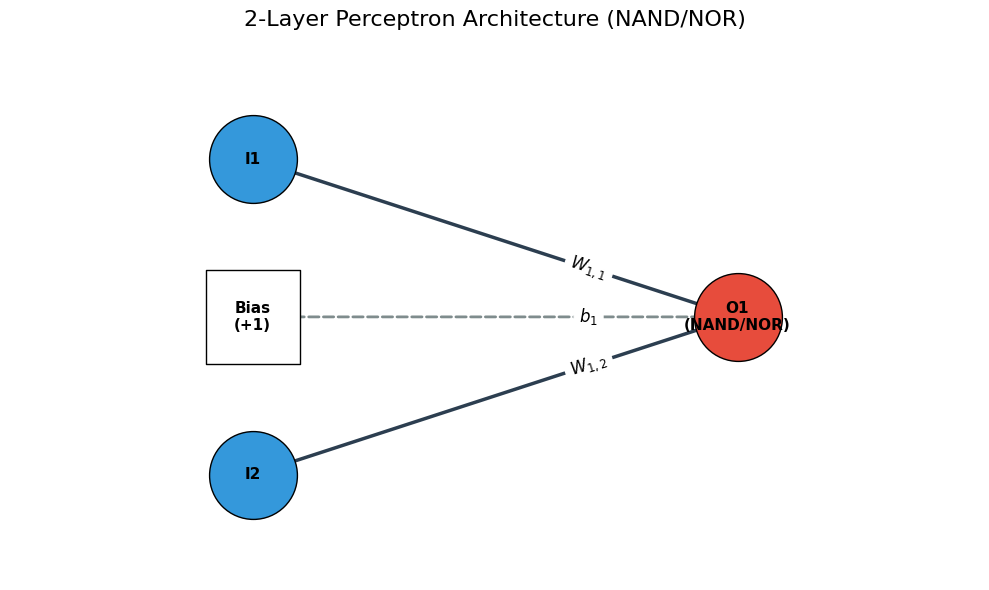

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_logic_gate_perceptron():
    # Architecture: 2 Inputs, 1 Bias -> 1 Output
    N_INPUT = 2
    N_OUTPUT = 1

    G = nx.DiGraph()
    pos = {}

    # Adjusted spread: Bringing I1 and I2 closer to the center to prevent clipping
    Y_SPREAD = 1.2

    # --- 1. Define Node Positions ---
    # Input Layer (x=0)
    pos[0] = (0, Y_SPREAD)     # I1 (Shifted down relative to previous 2.0 spread)
    pos[1] = (0, -Y_SPREAD)    # I2 (Shifted up relative to previous 2.0 spread)
    G.add_node(0, label='I1')
    G.add_node(1, label='I2')

    # BIAS NODE: Placed at x=0, at the origin
    BIAS_NODE_ID = "BIAS"
    pos[BIAS_NODE_ID] = (0, 0)
    G.add_node(BIAS_NODE_ID, label='Bias\n(+1)')

    # Output Layer (x=1)
    pos[2] = (1, 0) # O1
    G.add_node(2, label='O1\n(NAND/NOR)')

    # --- 2. Define Edges and Labels ---
    edge_labels = {}
    primary_edges = []
    bias_edges = []

    # Weights: Input -> Output
    for n in range(N_INPUT):
        u, v = n, 2
        G.add_edge(u, v)
        primary_edges.append((u, v))
        edge_labels[(u, v)] = f'$W_{{1,{n+1}}}$'

    # Bias Weight: Bias -> Output
    u, v = BIAS_NODE_ID, 2
    G.add_edge(u, v)
    bias_edges.append((u, v))
    edge_labels[(u, v)] = f'$b_{1}$'

    # --- 3. Rendering ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=[0, 1], node_color='#3498db', node_size=4000, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=[2], node_color='#e74c3c', node_size=4000, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=[BIAS_NODE_ID], node_color='white', node_shape='s', node_size=4500, edgecolors='black')

    # Labels
    nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'), font_size=11, font_weight='bold')

    # Edges
    nx.draw_networkx_edges(G, pos, edgelist=primary_edges, edge_color='#2c3e50', width=2.5, arrowsize=30)
    nx.draw_networkx_edges(G, pos, edgelist=bias_edges, edge_color='#7f8c8d', style='dashed', width=2, arrowsize=25)

    # Edge Labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.7)

    plt.title("2-Layer Perceptron Architecture (NAND/NOR)", fontsize=16, pad=20)

    # Explicitly setting limits to ensure the circles have "breathing room"
    plt.xlim(-0.5, 1.5)
    plt.ylim(-2.0, 2.0)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_logic_gate_perceptron()

# 2. Implementation: Training & Inference of Logic Gates

### Objective
In this section, we implement the **Training Loop** using NumPy. You will observe how a system with no pre-programmed logic "converges" on the correct Truth Table through iterative weight updates.

---

### 1. The Inference Engine (The Forward Pass)
During **Inference**, the hardware performs a single **Multiply-Accumulate (MAC)** operation followed by an activation. This is the same process used in modern NPUs, just scaled down to a single neuron.

* **Dot Product:** $z = (W_1 \cdot I_1) + (W_2 \cdot I_2) + b$
* **Activation:** $Output = \text{Sigmoid}(z)$
    * *Note: The Sigmoid function simulates the non-linear switching behavior of a transistor, squishing the output between 0 (LOW) and 1 (HIGH).*

---

### 2. The Training Process (The Backward Pass)
Training is the process of finding the specific **Weights** and **Bias** that satisfy the Truth Table. We use **Gradient Descent** to minimize the error.

| Step | Hardware Action | Description |
| :--- | :--- | :--- |
| **Forward** | Compute Output | The current weight registers are used to predict the logic state. |
| **Error** | Calculate Loss | We compare the prediction to the Target (e.g., NAND target). |
| **Backward** | Update Weights | We adjust the $W$ and $b$ registers in the direction that reduces the error. |

---

### 3. Monitoring Convergence
As you run the code below, pay attention to the **Mean Squared Error (MSE)**.
* **Initial State:** The weights are random; the "gate" produces garbage output.
* **Learning Phase:** The error drops sharply as the weights begin to represent the logic boundary.
* **Convergence:** The error nears zero. The hardware is now "programmed" as a functional logic gate.

---

### Hardware Discussion Questions
1. **The Learning Rate ($\eta$):** If the learning rate is too high, the weights may oscillate and never "lock in" to the correct logic. How does this compare to a "noisy" feedback loop in an analog circuit?
2. **Precision:** We are using 64-bit floats here. If we used **4-bit integers (INT4)** to save power on an AI chip, would we still be able to represent a simple NAND gate?
3. **Static vs. Dynamic:** A hard-wired CMOS NAND gate is faster and more efficient. What is the **one major advantage** of using this Perceptron-based gate instead?

In [6]:
import numpy as np

# --- 1. DATASET: The Truth Tables ---
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y_nand = np.array([[1], [1], [1], [0]])
y_nor  = np.array([[1], [0], [0], [0]])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def train_with_monitoring(inputs, targets, name, epochs=2000, interval=400, lr=0.5):
    # Initialize 2-layer parameters (Inputs -> Output)
    weights = np.random.randn(2, 1)
    bias = np.random.randn(1)

    print(f"\n--- Training {name} Logic Gate ---")
    print(f"{'Epoch':<8} | {'Mean Squared Error':<20}")
    print("-" * 35)

    for epoch in range(1, epochs + 1):
        # 1. Forward Pass (Dot Product + Activation)
        z = np.dot(inputs, weights) + bias
        output = sigmoid(z)

        # 2. Calculate Error (MSE)
        error = targets - output
        mse = np.mean(np.square(error))

        # 3. Print Progress at Interval
        if epoch % interval == 0 or epoch == 1:
            print(f"{epoch:<8} | {mse:<20.6f}")

        # 4. Backpropagation (Gradient Update)
        # derivative of sigmoid is output * (1 - output)
        adjustment = error * (output * (1 - output))
        weights += np.dot(inputs.T, adjustment) * lr
        bias += np.sum(adjustment) * lr

    # FINAL VERIFICATION
    print("\nFinal Truth Table Results:")
    final_output = sigmoid(np.dot(inputs, weights) + bias)
    for i in range(4):
        state = "HIGH" if final_output[i] > 0.5 else "LOW"
        print(f"Input: {inputs[i]} | Predicted: {final_output[i][0]:.4f} -> {state}")

    print(f"\nLearned HW Config: w={weights.flatten().round(2)}, b={bias.round(2)}")

# Run the simulations
train_with_monitoring(X, y_nand, "NAND", interval=500)
train_with_monitoring(X, y_nor, "NOR", interval=500)


--- Training NAND Logic Gate ---
Epoch    | Mean Squared Error  
-----------------------------------
1        | 0.421117            
500      | 0.012873            
1000     | 0.005826            
1500     | 0.003683            
2000     | 0.002671            

Final Truth Table Results:
Input: [0 0] | Predicted: 0.9998 -> HIGH
Input: [0 1] | Predicted: 0.9441 -> HIGH
Input: [1 0] | Predicted: 0.9441 -> HIGH
Input: [1 1] | Predicted: 0.0665 -> LOW

Learned HW Config: w=[-5.47 -5.47], b=[8.29]

--- Training NOR Logic Gate ---
Epoch    | Mean Squared Error  
-----------------------------------
1        | 0.177481            
500      | 0.006164            
1000     | 0.002853            
1500     | 0.001828            
2000     | 0.001337            

Final Truth Table Results:
Input: [0 0] | Predicted: 0.9452 -> HIGH
Input: [0 1] | Predicted: 0.0342 -> LOW
Input: [1 0] | Predicted: 0.0342 -> LOW
Input: [1 1] | Predicted: 0.0001 -> LOW

Learned HW Config: w=[-6.19 -6.19], b=[2.85]
